## Online Retail Satış Analizi ve Zaman Serisi İncelemesi

**Amaç:** Bu çalışma, Online Retail veri seti üzerinden satış trendlerini, en çok gelir getiren ürünleri ve ülke bazlı gelir dağılımını analiz etmeyi amaçlamaktadır.

Müşteri bazlı derin analiz (RFM vb.) ayrı bir adımda yapılacaktır.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [3]:
df = pd.read_excel("/home/buluag/portfolio/data_analysis/online_retail_analysis/Online Retail.xlsx")
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


## 1. Veri Keşfi ve Temizleme

1.1. Veri yapısını inceleme:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


1.2. Eksik Değerleri Tespit etme:

In [6]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

1.3. Description sütunundaki boş olan satırları silme:

In [7]:
# description sütunundaki boş satırları silme
df = df.dropna(subset=['Description'])

# Quantity (Miktar) ve UnitPrice (Birim Fiyat) sıfır veya negatif olanları temizleme
df = df[(df["Quantity"]>0) & (df["UnitPrice"] > 0)]

CustomerID eksikliği,genel satış trendleri, en çok satan ürünler ve ülke bazlı gelir dağılımı gibi analizleri doğrudan etkilemez. Bu yüzden analizin ilk aşamasında bu kayıtlar doldurma/silme yapmadan kullanılabilir.

RFM analizi için mutlaka geçerli bir CustomerID'ye ihtiyaç vardır. Bu nedenle, RFM analizine geçerken, bu 135,080 kaydı analizden tamamen çıkarmak gerekecektir.

Ayrıca, Quantity (Miktar) ve UnitPrice (Birim Fiyat) sıfır veya negatif olanlar temizlenmelidir.


In [8]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132220
Country             0
dtype: int64

## 2. Satış Trendlerini Analiz Etme

2.1. Revenue (gelir) hesaplama (Revenue = Quantity x UnitPrice):

In [9]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [10]:
print(df.dtypes)

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
Revenue               float64
dtype: object


2.2. Aylık Toplam Gelir Hesaplama

In [11]:
# Aylık periyot oluşturma
df["InvoiceMonthYear"] = df["InvoiceDate"].dt.to_period("M")
print(df["InvoiceMonthYear"].head())

# Yıl-ay periyoduna göre gelirleri gruplandırıp toplama:
monthly_revenue = df.groupby("InvoiceMonthYear")["Revenue"].sum().reset_index()
print(monthly_revenue.head())

0    2010-12
1    2010-12
2    2010-12
3    2010-12
4    2010-12
Name: InvoiceMonthYear, dtype: period[M]
  InvoiceMonthYear     Revenue
0          2010-12  823746.140
1          2011-01  691364.560
2          2011-02  523631.890
3          2011-03  717639.360
4          2011-04  537808.621


**Aylık Satış Trendlerini Görselleştirme**

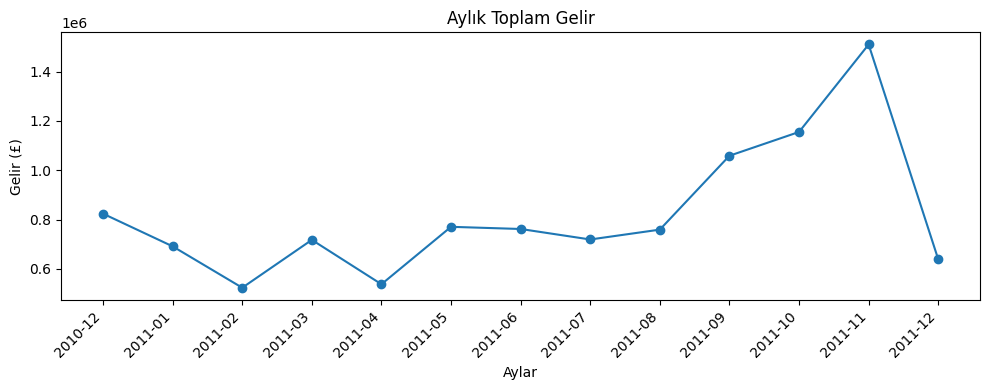

In [12]:
monthly_revenue["Month"] = monthly_revenue["InvoiceMonthYear"].astype(str)

x = monthly_revenue["Month"]
y = monthly_revenue["Revenue"]

plt.figure(figsize=(10,4))
plt.plot(x, y, marker="o")
plt.title("Aylık Toplam Gelir")
plt.xlabel("Aylar")
plt.ylabel("Gelir (£)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

- Yılın ocak ve ağustos aylarında gelir 500.000 ile 700.000 arasında dalgalanmaktadır.

- Eylülden itibaren gelirde artış yaşanmaya başlıyor. Okulların açılmasıyla yapılan alışverişlerde bir miktar artış olmuş olabilir.

- Kasım 2011'de muhtemelen Kara Cuma ve Noel alışverişi yapılmasıyla gelirde mevsimsel bir atış söz konusudur.

## 3. Ülkelere Göre Gelir Dağılımı

**Amaç:** Her ülkenin toplam gelire ne kadar katlı sağladığını hesaplamak.

In [13]:
country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
print(country_revenue)

Country
United Kingdom    9025222.084
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209715.110
Australia          138521.310
Spain               61577.110
Switzerland         57089.900
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64


In [14]:
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  Revenue  \
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom    15.30   
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34   
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom    22.00   
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34   
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34   

  InvoiceMonthYear  
0          2010-12  
1          2010-12  
2          2010-12  
3          2010-12  
4          2010-12  


**En çok satış yapılan ülkeler grafiği (10 ülke)**

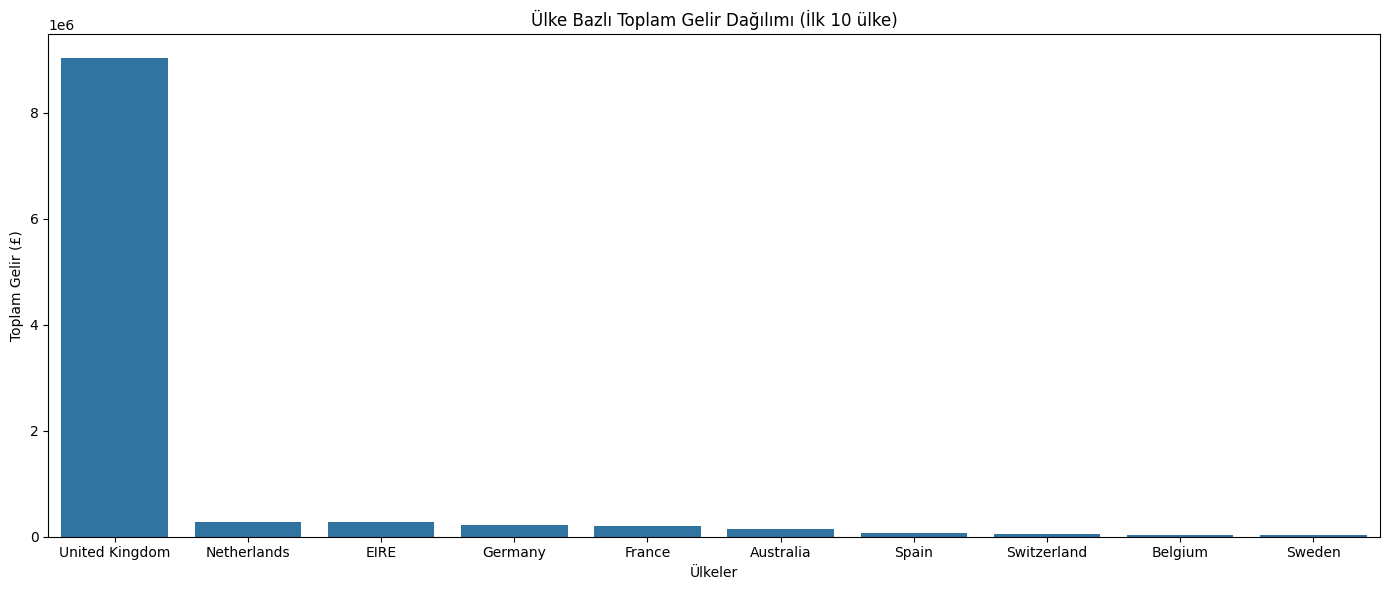

In [15]:
country_revenue_df = country_revenue.to_frame().reset_index()

plt.figure(figsize=(14, 6))

sns.barplot(x = "Country", y = "Revenue", data=country_revenue_df)

plt.title("Ülke Bazlı Toplam Gelir Dağılımı (İlk 10 ülke)")
plt.xlabel("Ülkeler")
plt.ylabel("Toplam Gelir (£)")

plt.tight_layout()
plt.show()

**UK Hariç Uluslararası Gelir Dağılımı**

In [16]:
df_non_uk = df[df["Country"] != "United Kingdom"]

# Ülkelere göre toplam gelir (İngiltere hariç)
top_countries_revenue = df_non_uk.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10).reset_index()
print(top_countries_revenue)

       Country    Revenue
0  Netherlands  285446.34
1         EIRE  283453.96
2      Germany  228867.14
3       France  209715.11
4    Australia  138521.31
5        Spain   61577.11
6  Switzerland   57089.90
7      Belgium   41196.34
8       Sweden   38378.33
9        Japan   37416.37


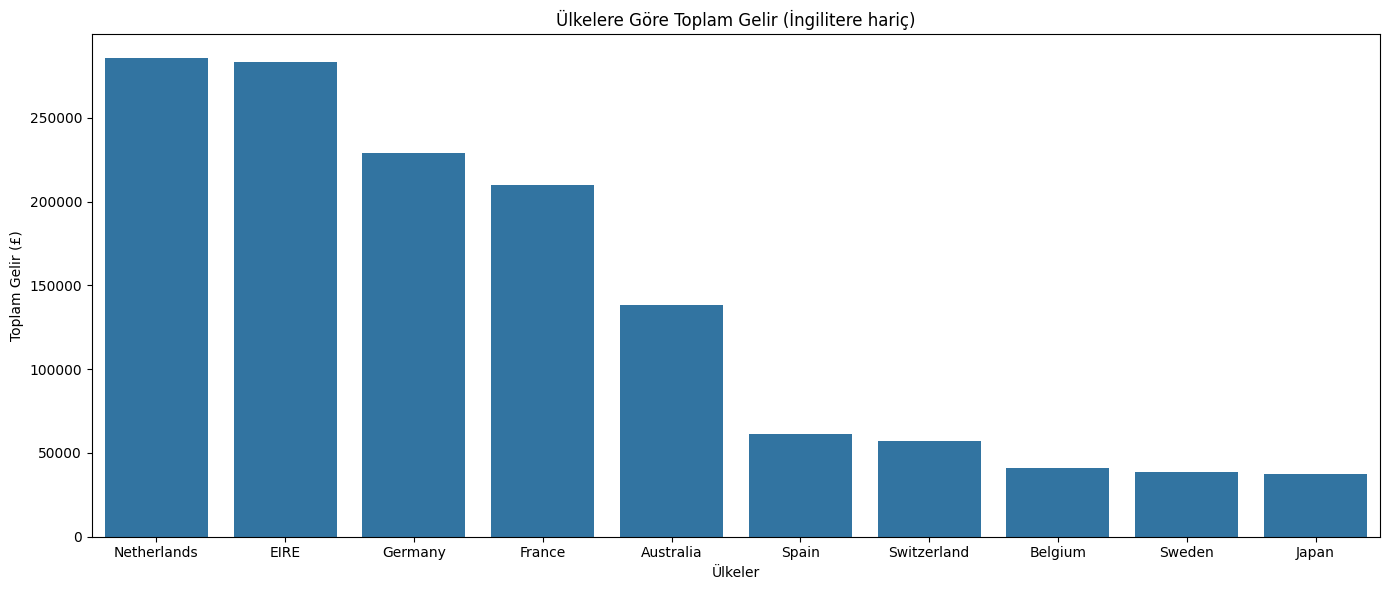

In [17]:
plt.figure(figsize=(14, 6))

sns.barplot(x="Country", y="Revenue", data=top_countries_revenue)

plt.title("Ülkelere Göre Toplam Gelir (İngilitere hariç)")
plt.xlabel("Ülkeler")
plt.ylabel("Toplam Gelir (£)")

plt.tight_layout()
plt.show()

Uluslarası Pazar Analizi Yorumu

- İngiltere hariç en yüksek geliri Hollanda sağlıyor (Yaklaşık 280.000£). Bu ülke, uluslararası pazarlama ve dağıtım stratejilerinin odak noktası olmalıdır.

- Hollanda'yı çok yakın takip eden İrlanda (EIRE), Almanya (Germany) ve Fransa (France) ile birlikte birincil uluslararası müşteri grubunu oluşturuyor.

Bu perakendecinin uluslararası büyüme stratejisi, mevcut kaynakları Hollanda, İrlanda, Almanya ve Fransa pazarlarına yoğunlaştırmalıdır.

## RFM (Recency, Frequency, Monetary) Analizi

RFM müşterileri segmentlemek ve mevcut müşteri durumunu incelemek amacıyla uygulanan bir metoddur.

| Harf              | Anlamı        | Açıklama                                |
| ----------------- | ------------- | --------------------------------------- |
| **R (Recency)**   | Yenilik       | Müşterinin son alışverişinden bugüne kadar geçen zaman | |
| **F (Frequency)** | Sıklık        | Müşteri ne sıklıkla alışveriş yaptı     |
| **M (Monetary)**  | Parasal değer | Müşteri toplamda ne kadar harcama yaptı |

Müşterileri bu 3 kritere göre puanlayarak en değerli (sadık ve kârlı) müşteri segmentlerini bulmak ve pazarlama stratejilerini (elde tutma, yeniden aktivasyon) kişiselleştirmektir.

In [18]:
# CustomerID boş olan satırları silip yeni dataframe oluşturma
df_rfm = df.dropna(subset=["CustomerID"])

df_rfm.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID          0
Country             0
Revenue             0
InvoiceMonthYear    0
dtype: int64

Quantity sütununda negatif değerler iade edildiğini gösterirken pozitif değerler satışın gerçekleştiğini gösteriyor. RFM analizi için yalnızca gerçekleşen satışları (Quantity > 0 olanları) tutmalıyız.

In [19]:
df_rfm = df_rfm[df_rfm["Quantity"]>0].copy()
df_rfm.info()

df_rfm["CustomerID"] = df_rfm["CustomerID"].astype(str)
df_rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   InvoiceNo         397884 non-null  object        
 1   StockCode         397884 non-null  object        
 2   Description       397884 non-null  object        
 3   Quantity          397884 non-null  int64         
 4   InvoiceDate       397884 non-null  datetime64[ns]
 5   UnitPrice         397884 non-null  float64       
 6   CustomerID        397884 non-null  float64       
 7   Country           397884 non-null  object        
 8   Revenue           397884 non-null  float64       
 9   InvoiceMonthYear  397884 non-null  period[M]     
dtypes: datetime64[ns](1), float64(3), int64(1), object(4), period[M](1)
memory usage: 33.4+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column            Non-Null 

In [20]:
musteri_sayisi = df_rfm['CustomerID'].nunique()
print(f"Toplam Müşteri Sayısı (Benzersiz ID): {musteri_sayisi}")

Toplam Müşteri Sayısı (Benzersiz ID): 4338


Referans tarihi belirleme

In [21]:
# veri setindeki en son işlem tarihi
last_date = df_rfm["InvoiceDate"].max()

# referans Tarihi (son tarihten 1 gün sonrası)
snapshot_date = last_date + dt.timedelta(days=1)

print(f"Referans tarihi: {snapshot_date}")

Referans tarihi: 2011-12-10 12:50:00


In [22]:
# müşteri bazında R, F ve M değerlerini tek bir tabloda topla
df_rfm = df_rfm.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
})

#print(df_rfm)

# sütun isimlerini RFM olarak yeniden adlandırma
df_rfm.rename(columns={"InvoiceDate": "R",
                       "InvoiceNo": "F",
                       "Revenue": "M"}, inplace=True)

print("RFM DEĞERLERİNİN İLK 5 MÜŞTERİSİ VE ÖZETİ")
print(df_rfm.head())

print("\nRFM DEĞERLERİNİN İSTATİSTİKSEL ÖZETİ:")
print(df_rfm.describe())


RFM DEĞERLERİNİN İLK 5 MÜŞTERİSİ VE ÖZETİ
              R  F         M
CustomerID                  
12346.0     326  1  77183.60
12347.0       2  7   4310.00
12348.0      75  4   1797.24
12349.0      19  1   1757.55
12350.0     310  1    334.40

RFM DEĞERLERİNİN İSTATİSTİKSEL ÖZETİ:
                 R            F              M
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2054.266460
std     100.014169     7.697998    8989.230441
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     307.415000
50%      51.000000     2.000000     674.485000
75%     142.000000     5.000000    1661.740000
max     374.000000   209.000000  280206.020000


In [23]:
# her biri için 1-5 puan ver
df_rfm["R_Score"] = pd.qcut(df_rfm["R"], q=5, labels=[5,4,3,2,1]).astype(int)
df_rfm["F_Score"] = pd.qcut(df_rfm["F"].rank(method="first"), q=5, labels=[1,2,3,4,5]).astype(int)
df_rfm["M_Score"] = pd.qcut(df_rfm["M"].rank(method="first"), q=5, labels=[1,2,3,4,5]).astype(int)

# 4. RFM skorunu birleştirme
df_rfm["RFM_Score"] = df_rfm["R_Score"].astype(str) + df_rfm["F_Score"].astype(str) + df_rfm["M_Score"].astype(str)

print("\n RFM Puanları Hesaplanmış İlk 5 Müşteri ")
print(df_rfm.head())


 RFM Puanları Hesaplanmış İlk 5 Müşteri 
              R  F         M  R_Score  F_Score  M_Score RFM_Score
CustomerID                                                       
12346.0     326  1  77183.60        1        1        5       115
12347.0       2  7   4310.00        5        5        5       555
12348.0      75  4   1797.24        2        4        4       244
12349.0      19  1   1757.55        4        1        4       414
12350.0     310  1    334.40        1        1        2       112


In [27]:
def rfm_segment(df):
    # en iyi müşteriler: R, F, M yüksek
    if df["R_Score"] >= 4 and df['F_Score'] >= 4 and df['M_Score'] >= 4:
        return "Sadık Şampiyon"
    # yeni Müşteriler: R yüksek, F ve M düşük
    elif df["R_Score"] >= 4 and df["F_Score"] < 2:
        return "Yeni Müşteri"
    # risk Altındaki Müşteriler: R düşük, F ve M yüksek
    elif df["R_Score"] <= 2 and df["F_Score"] >= 4:
        return "Risk Altında (Eski Sadık)"
    # kaybedilmiş Müşteriler: R, F, M düşük
    elif df["R_Score"] <= 2 and df["F_Score"] <= 2:
        return "Kaybedilmiş Müşteri"
    # geri kalanlar (Potansiyel, Uykuya Dalmış vb.)
    else:
        return "Potansiyel/Diğer"

# apply() fonksiyonu ile her müşteriye segment ataması yapalım
df_rfm["Segment"] = df_rfm.apply(rfm_segment, axis=1)

print("\n RFM Segment Dağılımı (Segment Sayıları) ")
print(df_rfm['Segment'].value_counts())
print("\n Sadık Şampiyonlar Segmenti (İlk 5) ")
print(df_rfm[df_rfm['Segment'] == 'Sadık Şampiyon'].head())


 RFM Segment Dağılımı (Segment Sayıları) 
Segment
Potansiyel/Diğer             1895
Kaybedilmiş Müşteri          1065
Sadık Şampiyon                962
Risk Altında (Eski Sadık)     275
Yeni Müşteri                  141
Name: count, dtype: int64

 Sadık Şampiyonlar Segmenti (İlk 5) 
             R   F        M  R_Score  F_Score  M_Score RFM_Score  \
CustomerID                                                         
12347.0      2   7  4310.00        5        5        5       555   
12362.0      3  10  5226.23        5        5        5       555   
12364.0      8   4  1313.10        5        4        4       544   
12380.0     22   4  2724.81        4        4        5       445   
12381.0      5   5  1845.31        5        4        4       544   

                   Segment  
CustomerID                  
12347.0     Sadık Şampiyon  
12362.0     Sadık Şampiyon  
12364.0     Sadık Şampiyon  
12380.0     Sadık Şampiyon  
12381.0     Sadık Şampiyon  


In [25]:
# Müşteri segmentlerini R, F, M ortalamalarına göre özetleme ve sıralama
segment_ozet = df_rfm.groupby('Segment')[['R', 'F', 'M']].mean().sort_values(by='M', ascending=False)

print("\n--- RFM Segmentlerinin Ortalama Değer Özeti (M'ye Göre Sıralı) ---")
print(segment_ozet.to_string(float_format="%.2f"))


--- RFM Segmentlerinin Ortalama Değer Özeti (M'ye Göre Sıralı) ---
                               R     F       M
Segment                                       
Sadık Şampiyon             12.86 11.08 6038.82
Risk Altında (Eski Sadık) 137.08  4.89 1575.41
Potansiyel/Diğer           61.57  2.75 1107.09
Kaybedilmiş Müşteri       217.90  1.10  487.71
Yeni Müşteri               18.50  1.00  365.14


Elde edilen RFM segmentasyon sonuçları, Sadık Şampiyonlar grubunun (Ortalama M: 6038 £ / Ortalama F: 11 işlem) şirketin cirosu için önemlidir. Bu müşterileri elde tutmak, yeni müşteri kazanmaktan çok daha karlıdır. Bu nedenle, bu gruba yönelik yönelik ayrıcalıklı teklifler sunulmalıdır. 

En büyük risk, Risk Altında segmentinde görülmektedir. Bu grup, geçmişte kârlı olmasına rağmen (Ortalama M: 1570 £), 137 gündür alım yapmamaktadır. Bu 276 müşterinin kaybını önlemek için kişiye özel, cazip tekliflerle hemen harekete geçmek gerekmektedir.

Son olarak, Yeni Müşterilerin ortalama harcaması (362 £) düşüktür. Pazarlama stratejisi, bu yeni kitlede güven inşa etmeye ve ilk alımdan sonra ikinci alışı teşvik etmeye odaklanmalıdır.

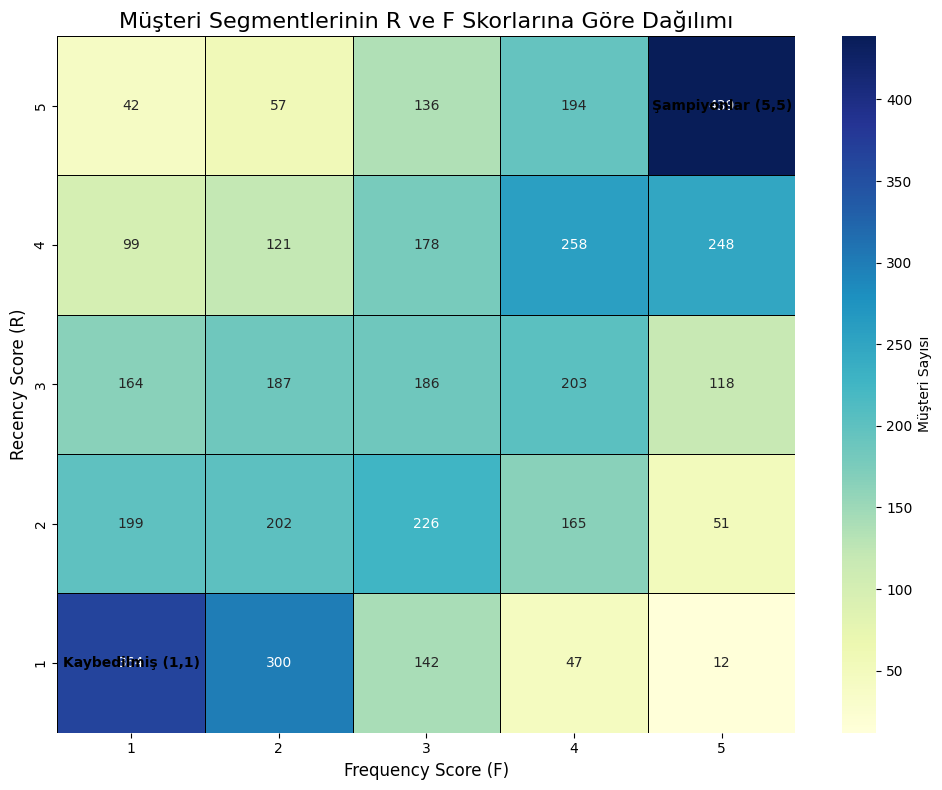

In [26]:
rf_matrix = df_rfm.groupby(['R_Score', 'F_Score']).size().unstack(fill_value=0)

rf_matrix = rf_matrix.sort_index(ascending=False) 

plt.figure(figsize=(10, 8))
sns.heatmap(
    rf_matrix,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Müşteri Sayısı'}
)

plt.title('Müşteri Segmentlerinin R ve F Skorlarına Göre Dağılımı', fontsize=16)
plt.xlabel('Frequency Score (F)', fontsize=12)
plt.ylabel('Recency Score (R)', fontsize=12)

plt.text(4.5, 0.5, 'Şampiyonlar (5,5)', ha='center', va='center', color='black', fontsize=10, weight='bold') 

plt.text(0.5, 4.5, 'Kaybedilmiş (1,1)', ha='center', va='center', color='black', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()